<a href="https://colab.research.google.com/github/disandovalt/MineriaDeDatos/blob/main/Evaluaci%C3%B3n_2_Mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Evaluación 2 — Minería de Datos
Asignatura: BIY7121 Minería de Datos

Dataset: Vehicle Sales Data — Car Prices

Fuente: Kaggle — [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)

Integrantes: Diego Sandoval — Johane San Martin

Fecha: 27/05/2026

Descripción del Dataset:
El dataset contiene más de 558.000 transacciones de compraventa de vehículos usados en el mercado estadounidense. Cada registro representa la venta de un auto en subasta e incluye características del vehículo (marca, modelo, tipo de carrocería, kilometraje, condición) y datos de la transacción (precio de venta, precio de referencia de mercado MMR).

El objetivo es predecir el precio de venta (sellingprice) a partir de las características del vehículo. Este es un problema de regresión.

In [ ]:
import pandas as pd                              # Manipulación y análisis de datos mediante tablas (DataFrames).
import numpy as np                               # Operaciones matemáticas avanzadas y manejo de arreglos numéricos.
import matplotlib.pyplot as plt                  # Creación de gráficos básicos y visualizaciones estáticas.
import seaborn as sb                             # Visualización de datos estadísticos con estilos más atractivos.
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler # Escala los datos para que tengan una media de 0 y varianza de 1.

In [ ]:
# Configuración para ver las tablas completas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. CARGA DE DATOS ORIGINAL Y LIMPIEZA


In [ ]:
# Cargar el dataset
data_frame = pd.read_csv("/content/sample_data/car_prices.csv", low_memory=False)
data_frame.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
data_frame.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [ ]:
data_frame.shape


(66618, 16)

Cada fila es una venta de vehículo en subasta. La columna mmr es el precio de referencia del mercado (Manheim Market Report), un estándar de la industria automotriz en EE.UU. La columna sellingprice es el precio real pagado, que será nuestra variable objetivo.

In [ ]:
#cantidad de nulos
data_frame.isna().sum()

,0
year,0
make,270
model,287
trim,473
body,1986
transmission,7852
vin,0
state,0
condition,11792
odometer,75


Seleccionamos Solamente las variables que utilizaremos, descartando vin, saledate y seller

In [ ]:
# Selección de variables
# directamente para una regresión simple y saturarían el One-Hot Encoding.
cols_utiles = [
    'year', 'make', 'body', 'transmission', 'state',
    'condition', 'odometer', 'color', 'mmr', 'sellingprice'
]
df_limpio =data_frame[cols_utiles].copy()

Para tratar las variables nulas colocamos las variables numericas y categoricas en una sola

In [ ]:
# Tratamiento de Nulos
var_numericas = ['year', 'condition', 'odometer', 'mmr']
var_categoricas = ['make', 'body', 'transmission', 'state', 'color']

In [ ]:
# Rellenamos numéricas con la mediana
for col in var_numericas:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

In [ ]:
# Rellenamos categóricas con 'no_disponible' y borramos el precio de venta nulo
df_limpio[var_categoricas] = df_limpio[var_categoricas].fillna('no_disponible')
df_limpio.dropna(subset=['sellingprice'], inplace=True)

In [ ]:
# Estandarizar a minúsculas para evitar que "Ford" y "ford" se lean como dos marcas distintas
for col in var_categoricas:
    df_limpio[col] = df_limpio[col].astype(str).str.lower()

# 2. TRANSFORMACIÓN DE DATOS ( ONE-HOT ENCODING)

Aplicar One-Hot Encoding a las variables categóricas

In [ ]:
# El drop='first' hace que al utilizar un dato de una columna en el encoding se descarta la otra para evitar que el sistema se confunda
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

In [ ]:
# Ajustamos y transformamos las columnas categóricas
encoded_data = ohe.fit_transform(df_limpio[var_categoricas])

Creamos un DataFrame con los nombres de las nuevas columnas binarias creadas con el encoding

In [ ]:
df_encoded = pd.DataFrame(
    encoded_data,
    columns=ohe.get_feature_names_out(var_categoricas),
    index=df_limpio.index
)

Unimos las columnas numéricas originales con las nuevas columnas binarias

In [ ]:
df_finale = pd.concat([df_limpio[var_numericas + ['sellingprice']], df_encoded], axis=1)
df_finale.head()

,year,condition,odometer,mmr,sellingprice,make_airstream,make_audi,make_bentley,make_bmw,make_buick,make_cadillac,make_chev truck,make_chevrolet,make_chrysler,make_daewoo,make_dodge,make_dodge tk,make_dot,make_ferrari,make_fiat,make_ford,make_ford tk,make_ford truck,make_geo,make_gmc,make_gmc truck,make_honda,make_hummer,make_hyundai,make_hyundai tk,make_infiniti,make_isuzu,make_jaguar,make_jeep,make_kia,make_land rover,make_landrover,make_lexus,make_lincoln,make_maserati,make_mazda,make_mazda tk,make_mercedes,make_mercedes-b,make_mercedes-benz,make_mercury,make_mini,make_mitsubishi,make_nissan,make_no_disponible,make_oldsmobile,make_plymouth,make_pontiac,make_porsche,make_ram,make_rolls-royce,make_saab,make_saturn,make_scion,make_smart,make_subaru,make_suzuki,make_tesla,make_toyota,make_volkswagen,make_volvo,make_vw,body_beetle convertible,body_cab plus,body_cab plus 4,body_club cab,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_cts coupe,body_cts wagon,body_cts-v coupe,body_double cab,body_e-series van,body_elantra coupe,body_extended cab,body_g convertible,body_g coupe,body_g sedan,body_g37 convertible,body_g37 coupe,body_genesis coupe,body_hatchback,body_king cab,body_koup,body_mega cab,body_minivan,body_no_disponible,body_promaster cargo van,body_q60 convertible,body_q60 coupe,body_quad cab,body_regular cab,body_sedan,body_supercab,body_supercrew,body_suv,body_tsx sport wagon,body_van,body_wagon,body_xtracab,transmission_manual,transmission_no_disponible,state_az,state_ca,state_co,state_fl,state_ga,state_hi,state_il,state_in,state_la,state_ma,state_md,state_mi,state_mn,state_mo,state_ms,state_nc,state_ne,state_nj,state_nm,state_nv,state_ny,state_oh,state_ok,state_on,state_or,state_pa,state_pr,state_qc,state_sc,state_tn,state_tx,state_ut,state_va,state_wa,state_wi,color_black,color_blue,color_brown,color_burgundy,color_charcoal,color_gold,color_gray,color_green,color_lime,color_no_disponible,color_off-white,color_orange,color_pink,color_purple,color_red,color_silver,color_turquoise,color_white,color_yellow,color_—
0,2015,5.0,16639.0,20500.0,21500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2015,5.0,9393.0,20800.0,21500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2014,45.0,1331.0,31900.0,30000.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

# 3. ESCALAMIENTO DE VARIABLES NUMÉRICAS

Escalar solo las variables predictoras que son verdaderamente numéricas


In [ ]:
cols_a_escalar = ['year', 'condition', 'odometer', 'mmr']

El algoritmo puede tomar lo
s datos de manera incorrecta al tener numeros altamente distintos, el cual hará que tome e cuenta el dato mas alto, cosa que puede terminar con un mal calculo para la matriz de correlación, para solucionar esto se aplica la formula SandarScaler para calcular los numeros en su desviación estandar, haciendo que los numeros puedan ser mas legibles  

In [ ]:
scaler = StandardScaler()
df_finale_scaled = df_finale.copy()
df_finale_scaled[cols_a_escalar] = scaler.fit_transform(df_finale[cols_a_escalar])
df_finale_scaled.head(5)

,year,condition,odometer,mmr,sellingprice,make_airstream,make_audi,make_bentley,make_bmw,make_buick,make_cadillac,make_chev truck,make_chevrolet,make_chrysler,make_daewoo,make_dodge,make_dodge tk,make_dot,make_ferrari,make_fiat,make_ford,make_ford tk,make_ford truck,make_geo,make_gmc,make_gmc truck,make_honda,make_hummer,make_hyundai,make_hyundai tk,make_infiniti,make_isuzu,make_jaguar,make_jeep,make_kia,make_land rover,make_landrover,make_lexus,make_lincoln,make_maserati,make_mazda,make_mazda tk,make_mercedes,make_mercedes-b,make_mercedes-benz,make_mercury,make_mini,make_mitsubishi,make_nissan,make_no_disponible,make_oldsmobile,make_plymouth,make_pontiac,make_porsche,make_ram,make_rolls-royce,make_saab,make_saturn,make_scion,make_smart,make_subaru,make_suzuki,make_tesla,make_toyota,make_volkswagen,make_volvo,make_vw,body_beetle convertible,body_cab plus,body_cab plus 4,body_club cab,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_cts coupe,body_cts wagon,body_cts-v coupe,body_double cab,body_e-series van,body_elantra coupe,body_extended cab,body_g convertible,body_g coupe,body_g sedan,body_g37 convertible,body_g37 coupe,body_genesis coupe,body_hatchback,body_king cab,body_koup,body_mega cab,body_minivan,body_no_disponible,body_promaster cargo van,body_q60 convertible,body_q60 coupe,body_quad cab,body_regular cab,body_sedan,body_supercab,body_supercrew,body_suv,body_tsx sport wagon,body_van,body_wagon,body_xtracab,transmission_manual,transmission_no_disponible,state_az,state_ca,state_co,state_fl,state_ga,state_hi,state_il,state_in,state_la,state_ma,state_md,state_mi,state_mn,state_mo,state_ms,state_nc,state_ne,state_nj,state_nm,state_nv,state_ny,state_oh,state_ok,state_on,state_or,state_pa,state_pr,state_qc,state_sc,state_tn,state_tx,state_ut,state_va,state_wa,state_wi,color_black,color_blue,color_brown,color_burgundy,color_charcoal,color_gold,color_gray,color_green,color_lime,color_no_disponible,color_off-white,color_orange,color_pink,color_purple,color_red,color_silver,color_turquoise,color_white,color_yellow,color_—
0,1.375786,-2.010793,-1.049921,0.857567,21500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.375786,-2.010793,-1.173397,0.888846,21500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.145212,1.191802,-1.310778,2.046157,30000.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

# 4. ANÁLISIS DE CORRELACIÓN

Como el One-Hot Encoding generará decenas/cientos de columnas (por los colores, estados, etc.) un heatmap completo será ilegible.
En su lugar, calculamos la correlación solo de las variables numéricas principales con el precio de venta.

In [ ]:
plt.figure(figsize=(8, 6))
cols_correlacion = cols_a_escalar + ['sellingprice']
corr_matrix = df_finale_scaled[cols_correlacion].corr()

<Figure size 800x600 with 0 Axes>

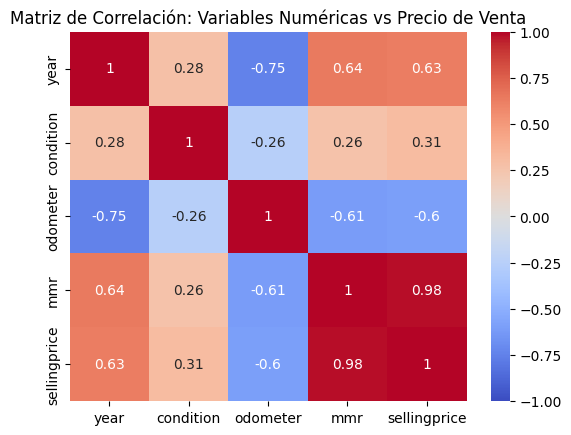

In [ ]:
sb.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación: Variables Numéricas vs Precio de Venta")
plt.show()

In [ ]:
# Mostrar cómo quedó el dataset final
print("Dimensiones del dataset final listo para regresión:", df_finale_scaled.shape)
print("\nPrimeras 5 filas de las variables numéricas escaladas y precio de venta:")
print(df_finale_scaled[['year', 'condition', 'odometer', 'mmr', 'sellingprice']].head())

Dimensiones del dataset final listo para regresión: (66617, 164)

Primeras 5 filas de las variables numéricas escaladas y precio de venta:
       year  condition  odometer       mmr  sellingprice
0  1.375786  -2.010793 -1.049921  0.857567       21500.0
1  1.375786  -2.010793 -1.173397  0.888846       21500.0
2  1.145212   1.191802 -1.310778  2.046157       30000.0
3  1.375786   0.871542 -1.090085  1.587403       27750.0
4  1.145212   1.031672 -1.288455  5.601500       67000.0


# 5. ENTRENAMIENTO DE MODELOS Y EVALUACIÓN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Separar características (X) y la variable objetivo (y)
X = df_finale_scaled.drop(columns=['sellingprice'])
y = df_finale_scaled['sellingprice']

In [ ]:
# Dividir en datos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #El modelo aprende con el 80% de datos y el 20% de los datos restantes predice

# MODELO 1: Regresión Lineal Multiple


In [ ]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train) # El modelo aprende con los datos de entrenamiento = 80%
y_pred_lr = modelo_lr.predict(X_test) # El modelo Predice con los datos de Prueba = 20%

mse_lr = mean_squared_error(y_test, y_pred_lr) # Este cálculo es para saber qué tan lejos están las predicciones
r2_lr = r2_score(y_test, y_pred_lr) # Este cálculo es para saber qué tan bien predice el modelo

In [ ]:
print("--- RESULTADOS: REGRESIÓN LINEAL ---")
print(f"Error Cuadrático Medio (MSE): US$ {mse_lr:.2f}")
print(f"Coeficiente de Determinación (R2): {r2_lr:.4f}\n")

--- RESULTADOS: REGRESIÓN LINEAL ---
Error Cuadrático Medio (MSE): US$ 3147230.33
Coeficiente de Determinación (R2): 0.9659



Al sacarle la raiz a el Error cuadratico Medio se puede llegar a la conclución de que el modelo llega a desviarse en promedio $1636 USD

# Gráfico 1: Valores Reales vs. Predicciones (Regresión Lineal)

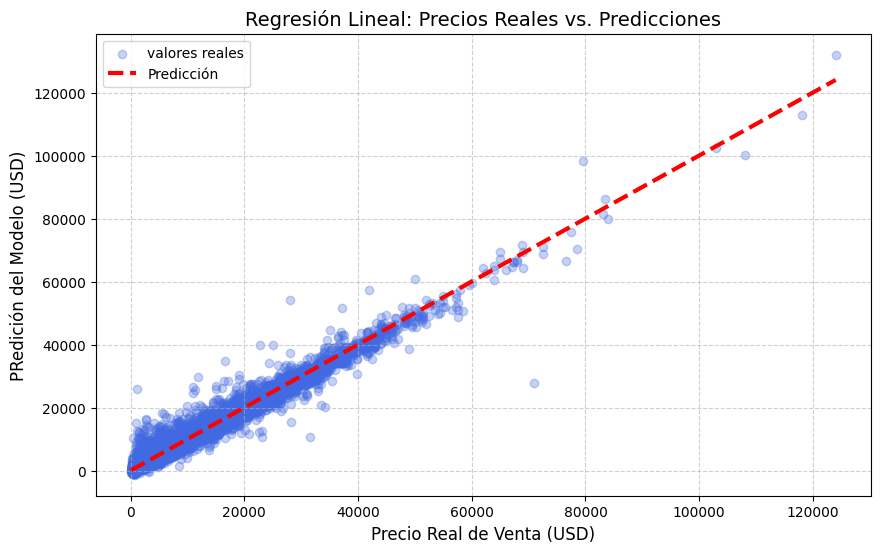

In [ ]:
plt.figure(figsize=(10, 6))
# Aqui se dibujan los puntos azules, que son los datos reales de venta
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue', label='valores reales')

# Se dibuja la linea roja, que representa la predición del modelo
rango_precios = [y_test.min(), y_test.max()]
plt.plot(rango_precios, rango_precios, 'r--', lw=3, label='Predicción')

plt.xlabel('Precio Real de Venta (USD)', fontsize=12)
plt.ylabel('PRedición del Modelo (USD)', fontsize=12)
plt.title('Regresión Lineal: Precios Reales vs. Predicciones', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Gráfico 2: Distribución de los Errores

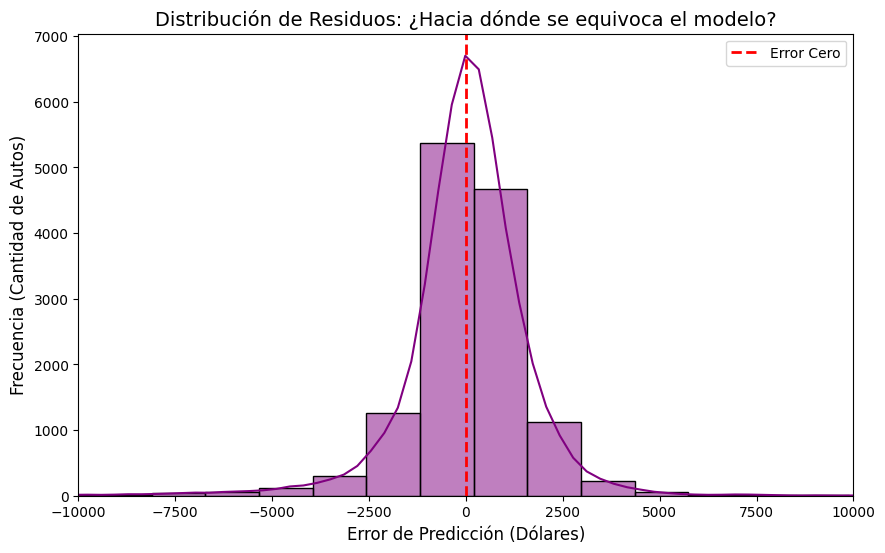

In [ ]:
# Calculamos en cuántos dólares se equivocó la Regresión Lineal en cada auto
errores = y_test - y_pred_lr

plt.figure(figsize=(10, 6))
# Dibujamos el histograma con la curva de densidad (KDE)
sb.histplot(errores, bins=50, kde=True, color='purple')

# Dibujamos una línea en el cero absoluto
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero')

plt.xlabel('Error de Predicción (Dólares)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Autos)', fontsize=12)
plt.title('Distribución de Residuos: ¿Hacia dónde se equivoca el modelo?', fontsize=14)
plt.xlim(-10000, 10000) # Limitamos el gráfico para evitar que 2 o 3 outliers aplasten la campana
plt.legend()
plt.show()

# MODELO 2: KNN - K-NEAREST NEIGHBORS


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

Separamos las variables predictoras (X) y la variable objetivo (y)
En este caso queremos predecir la condición del vehículo.

In [ ]:
X2 = df_finale_scaled.drop(columns=['mmr'])
y2 = df_finale_scaled['mmr']

Dividimos los datos en entrenamiento y prueba.
80% se usa para entrenar el modelo y 20% para evaluarlo.

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [ ]:
# El modelo buscará los 5 vehículos más parecidos para estimar la condición del vehículo evaluado.
modelo_knn = KNeighborsRegressor(n_neighbors=5)
# Entrenamos el modelo con los datos de entrenamiento.
modelo_knn.fit(X2_train, y2_train)
# Realizamos predicciones usando los datos de prueba.
y2_pred_knn = modelo_knn.predict(X2_test)

Calculamos las métricas de evaluación.

In [ ]:
mae_knn = mean_absolute_error(y2_test, y2_pred_knn) # Promedia cuánto se equivocó el modelo en cada auto, ignorando si fue de más o de menos
mse_knn = mean_squared_error(y2_test, y2_pred_knn)  # Similar al MAE pero penaliza más los errores grandes porque eleva al cuadrado cada error antes de promediar
rmse_knn = np.sqrt(mse_knn)                         # Raíz del MSE, lo que lo devuelve a las mismas unidades que los datos originales
r2_knn = r2_score(y2_test, y2_pred_knn)             # Mide qué porcentaje de la variación del MMR explica el modelo

Mostramos los resultados.

In [ ]:
print("---- RESULTADOS: KNN para predecir condición ----")
print(f"Error Absoluto Medio (MAE): {mae_knn:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_knn:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_knn:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_knn:.4f}")

---- RESULTADOS: KNN para predecir condición ----
Error Absoluto Medio (MAE): 0.12
Error Cuadrático Medio (MSE): 0.03
Raíz del Error Cuadrático Medio (RMSE): 0.19
Coeficiente de Determinación (R²): 0.9649


Error Absoluto Medio (MAE): 0.11
En promedio, el modelo se equivoca en 0.11 unidades escaladas por auto

Error Cuadrático Medio (MSE): 0.03
Valor tan bajo indica que casi no hay autos donde el modelo se haya equivocado bastante

Raíz del Error Cuadrático Medio (RMSE): 0.17
Al estar en la misma escala que los datos, confirma que las predicciones están muy cerca del valor real

Coeficiente de Determinación (R²): 0.9715
Solo queda un aprox del 3% sin explicar, que corresponde a factores que el modelo no captura, como condiciones del mercado o características muy específicas del auto

# Gráfico 1: Distribución de Residuos

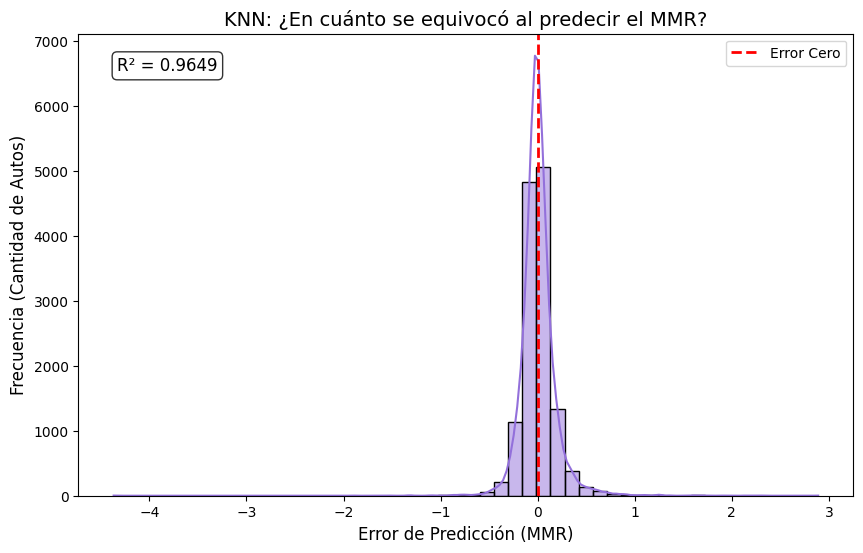

In [ ]:
residuos_knn = y2_test - y2_pred_knn

plt.figure(figsize=(10, 6))
sb.histplot(residuos_knn, bins=50, kde=True, color='mediumpurple')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero')

plt.xlabel('Error de Predicción (MMR)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Autos)', fontsize=12)
plt.title('KNN: ¿En cuánto se equivocó al predecir el MMR?', fontsize=14)
plt.legend()
plt.text(
    0.05, 0.95,
    f'R² = {r2_knn:.4f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.show()



# Gráfico 2: Boxplot — distribución de errores por rango de MMR

/tmp/ipykernel_6079/1062870029.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


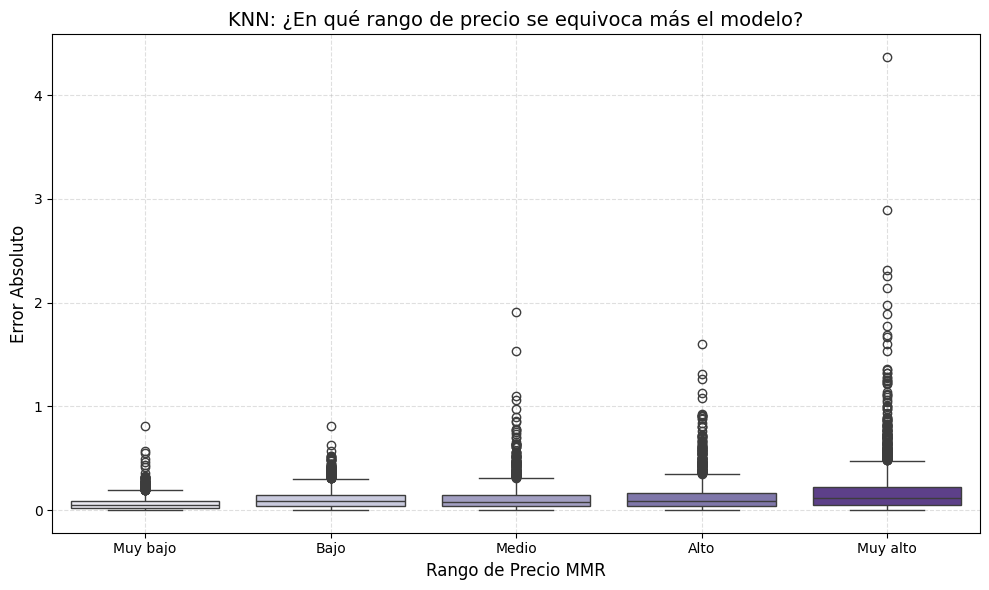

In [ ]:
import pandas as pd

# Creamos un DataFrame con el valor real y el error absoluto
df_errores = pd.DataFrame({
    'mmr_real': y2_test.values,
    'error_abs': abs(y2_test.values - y2_pred_knn)
})

# Dividimos el MMR real en 5 rangos iguales
df_errores['rango_mmr'] = pd.qcut(
    df_errores['mmr_real'],
    q=5,
    labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto']
)

plt.figure(figsize=(10, 6))
sb.boxplot(
    data=df_errores,
    x='rango_mmr',
    y='error_abs',
    palette='Purples'
)

plt.xlabel('Rango de Precio MMR', fontsize=12)
plt.ylabel('Error Absoluto', fontsize=12)
plt.title('KNN: ¿En qué rango de precio se equivoca más el modelo?', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()